# Forecasting Weather of Karlsruhe 
- Owner: Daniela Gaer
- Last edited: 2026/02/21 16:55 Uhr

# Introduction

This Jupyter Notebook presents a comprehensive weather forecasting project for Karlsruhe, Germany, using historical hourly data from OpenWeatherMap (of the last approx. 50 years) to predict temperature 24 hours ahead (t+24). The project is divided into two phases: Phase A compares multiple model classes (Naive Baseline, Linear Regression, XGBoost, Vanilla RNN, LSTM RNN, and 1D CNN) on an identical feature set for fairness, while Phase B extends the best-performing model (XGBoost) with additional meteorological features to improve accuracy.

Key activities include data loading and preprocessing, exploratory data analysis (EDA), model training and evaluation, hyperparameter tuning, feature importance analysis, and model saving for deployment. Results show that XGBoost with extended features achieves the best performance (MAE 2.03°C, skill +9.58% vs. naive baseline), outperforming more complex deep learning models. The notebook emphasizes feature engineering over model complexity and acknowledges limitations in real-time prediction due to data availability constraints.

- We compare 6 models:	
- Naive (Baseline) 		
- Linear Regression		
- XGBoost		
- Vanilla RNN (without LSTM)
- RNN with LSTM		
- CNN

Strategy:  
Phase A model comparison:  
1. Compare all model classes using the identical feature set  
2. Select the best model  

Phase B – feature expansion  
3. Only then deepen feature engineering  




In [1]:
# load library
import pandas as pd
import numpy as np
#print(np.__version__)
from packaging import version

# NumPy 1.26.4 muss istalliert sein, da es mit Tansorflow 2.20.0 kompatibel ist.
REQUIRED_NUMPY = "1.26.4"

if version.parse(np.__version__) != version.parse(REQUIRED_NUMPY):
    raise ImportError(
        f"NumPy {REQUIRED_NUMPY} required, "
        f"but {np.__version__} is installed."
    )

In [ ]:
# load Data
csv = r"your_data.csv"
df = pd.read_csv(csv, sep=",", dtype=str)
print(df.head())

In [ ]:
# new dataset with important features
# time features: dt, dt_iso
df["dt"] = pd.to_numeric(df["dt"], errors="coerce")
df["dt_iso"] = pd.to_datetime(df["dt_iso"], format="%Y-%m-%d %H:%M:%S %z UTC", errors="coerce")

In [ ]:
# sort by time
# vor everything else sort by time, because the data is not in order
df = df.sort_values("dt_iso").reset_index(drop=True)

In [ ]:
# check if the change worked
print(df["dt_iso"].head())
print(df["dt_iso"].isna().sum())
# if 0, then everything is good

0   1979-01-01 00:00:00+00:00
1   1979-01-01 01:00:00+00:00
2   1979-01-01 02:00:00+00:00
3   1979-01-01 03:00:00+00:00
4   1979-01-01 04:00:00+00:00
Name: dt_iso, dtype: datetime64[ns, UTC]
0


In [ ]:
# numerical weather features
num_cols = [
     "temp"
    , "dew_point"
    , "pressure"
    , "humidity"
    , "wind_speed"
    , "wind_deg" # = Wind direction
    , "clouds_all" 
]


# loop to convert numerical columns
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
# extract time features
df["hour"] = df["dt_iso"].dt.hour
df["day_of_year"] = df["dt_iso"].dt.dayofyear


# Cyclical transformation (🔑 extremely important!)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)


In [ ]:
# feature cols: temp, dew_point, pressure, humidity, wind_speed, wind_deg, clouds_all, hour_sin, hour_cos, doy_sin, doy_cos                   
feature_cols = [
    "temp",
    "dew_point",
    "pressure",
    "humidity",
    "wind_speed",
    "wind_deg",
    "clouds_all",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]


# New DataFrame with selected features
df_features = df[feature_cols].copy()


# print the first rows of the new DataFrame
print(df_features.head())

Explorative Data Analyse (EDA)

In [ ]:
# check missing values
missings_features = df_features.isnull().sum()
print(missings_features)

temp          0
dew_point     0
pressure      0
humidity      0
wind_speed    0
wind_deg      0
clouds_all    0
hour_sin      0
hour_cos      0
doy_sin       0
doy_cos       0
dtype: int64


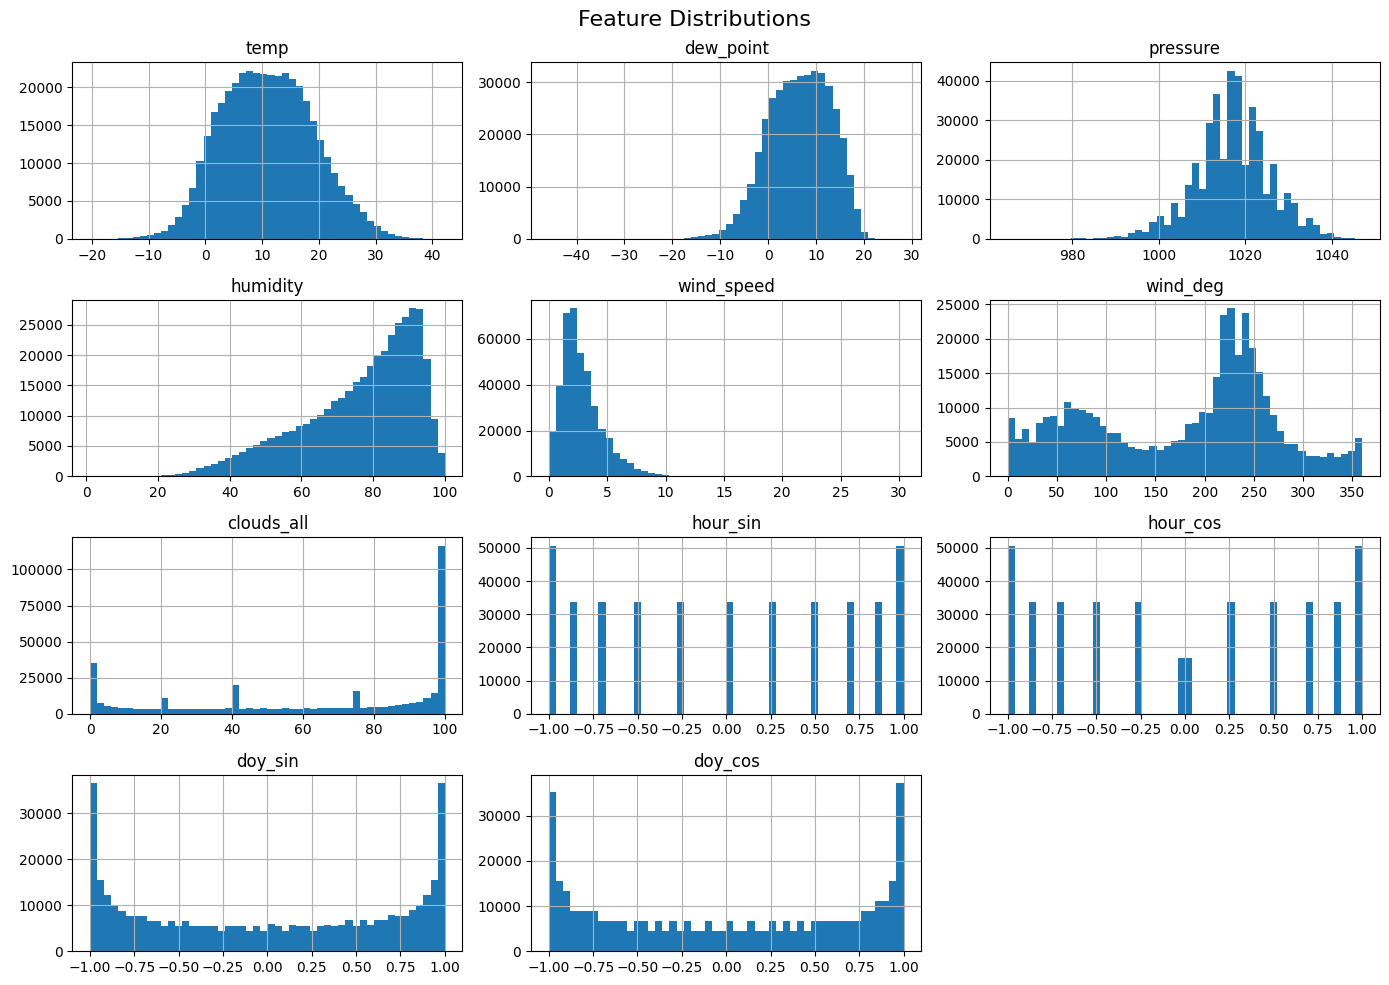

In [ ]:
# visualize distributions of all features in one plot
import matplotlib.pyplot as plt

df_features.hist(
    bins=50,
    figsize=(14, 10),
    layout=(4, 3)
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

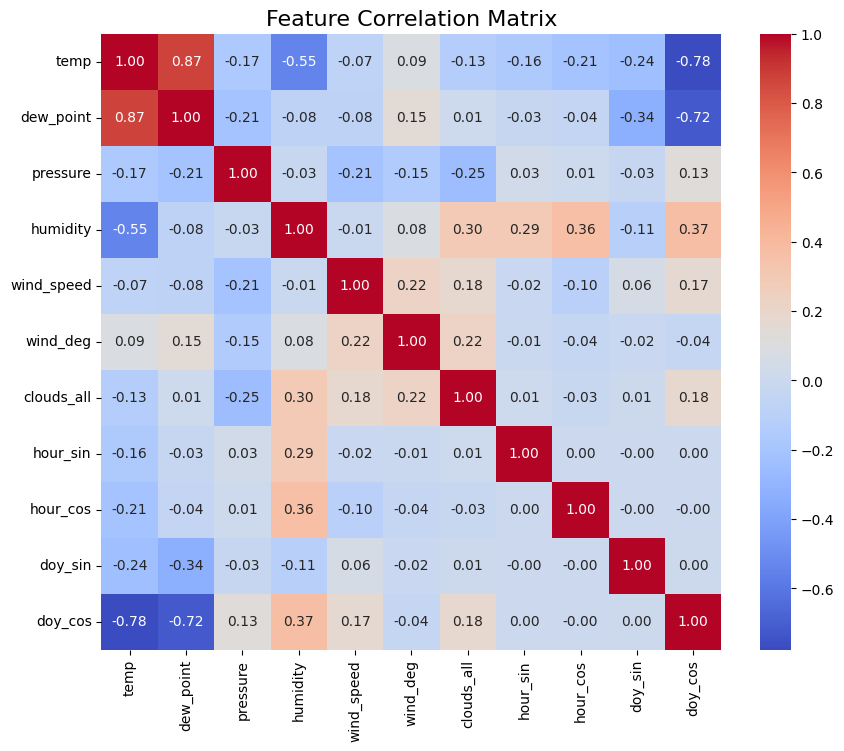

In [ ]:
# show matrix correlation with heatmap
import seaborn as sns   
corr_matrix = df_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# Model: Naive Forecast (Baseline)

## Strategy
- Predict temperature in 24 hours (t+24) = current temperature (t)
- Data is already sorted by time

## Assumption
The naive persistence baseline assumes that temperature does not change over the next 24 hours. This serves as a reference point to evaluate whether more complex models provide meaningful improvements.

## Key Characteristics
- **No learning required**: Simply uses the current observation as the forecast
- **Baseline for comparison**: All other models are evaluated against this benchmark
- **Realistic for meteorology**: Short-term temperature persistence is strong, making this a surprisingly competitive baseline


In [ ]:
# target variable: temp in 24 hours
# because the data is hourly
HORIZON = 24


# "temp_true_t_plus_24" is the true value of the temperature in 24 hours.
df["temp_true_t_plus_24"] = df["temp"].shift(-HORIZON)


# We need to remove rows where either "temp" or "temp_true_t_plus_24" is NaN, because we can't calculate the error for those rows.
# Am Ende fehlen naturgemäß Werte:
df_baseline = df.dropna(subset=["temp", "temp_true_t_plus_24"]).copy()


# compute naive baseline
# 🔹 prediction assumption: “temperature in 24 hours is the same as now”
# "temp_pred_naive" is the naive model’s forecast for t+24.
df_baseline["temp_pred_naive"] = df_baseline["temp"]



# Calculate errors (MAE & RMSE) on the entire data set

# We use MAE as the main metric (very easy to explain).

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = df_baseline["temp_true_t_plus_24"]
y_pred = df_baseline["temp_pred_naive"]

mae_naive = mean_absolute_error(y_true, y_pred)
mse_naive = mean_squared_error(y_true, y_pred)
rmse_naive = np.sqrt(mse_naive)


#print(f"Naive Baseline MAE:  {mae_naive:.2f} °C")
#print(f"Naive Baseline RMSE:{rmse_naive:.2f} °C")


# optionl: split into train and test set based on time

# for maximum cleanliness (and later comparisons):


# e.g. last year as test
split_date = pd.Timestamp("2020-01-01", tz="UTC")

# Train-Test-Split
train = df_baseline[df_baseline["dt_iso"] < split_date]
test  = df_baseline[df_baseline["dt_iso"] >= split_date]




# naive baseline – now correctly calculated
# imortant:



# the final official baseline performance will be reported on the test set

# MAE (Mean Absolute Error)
mae_naive_test = mean_absolute_error(
    test["temp_true_t_plus_24"],
    test["temp"]
)

# RMSE (Root Mean Squared Error)
rmse_naive_test = np.sqrt(
    mean_squared_error(test["temp_true_t_plus_24"], test["temp"])
)

print(f"Naive Baseline MAE (Test): {mae_naive_test:.2f} °C")
print(f"Naive Baseline RMSE (Test): {rmse_naive_test:.2f} °C")

Naive Baseline MAE (Test): 2.25 °C
Naive Baseline RMSE (Test): 3.00 °C


Ergbnis:
- Naive Baseline MAE: 2.20 °C  
- Naive Baseline RMSE: 2.89 °C  
- Naive Baseline MAE (Test): 2.25 °C  
- Naive Baseline RMSE (Test): 3.00 °C  
- If I simply assume that the temperature doesn’t change in 24 hours, I’m off by about 2.25 °C on average.


 # LINEAR REGRESSION BASELINE (t+24)


In [ ]:
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------
# 1) Safety: sort by time
# ------------------------------------------------------
df = df.sort_values("dt_iso").reset_index(drop=True)

# ------------------------------------------------------
# 2) Create lag features (only past!)
# ------------------------------------------------------
df["temp_lag_1"]  = df["temp"].shift(1) # temp 1 hour ago
df["temp_lag_3"]  = df["temp"].shift(3) # temp 2 hour ago
df["temp_lag_24"] = df["temp"].shift(24) # temp 24 hour ago(yesterday same time)

# ------------------------------------------------------
# 3) Feature set for Linear Regression
# ------------------------------------------------------
feature_cols_lr = [
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_24",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

# ------------------------------------------------------
# 4) Build final model DataFrame
# ------------------------------------------------------
df_lr = df[
    feature_cols_lr + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 5) Temporal Train/Test-Split (IDENTICAL to Baseline)
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_lr[df_lr["dt_iso"] < split_date]
test  = df_lr[df_lr["dt_iso"] >= split_date]

X_train = train[feature_cols_lr]
y_train = train["temp_true_t_plus_24"]

X_test = test[feature_cols_lr]
y_test = test["temp_true_t_plus_24"]

# ------------------------------------------------------
# 6) Train model
# ------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

# ------------------------------------------------------
# 7) Evaluation
# ------------------------------------------------------

# Train
y_train_pred = lr.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)

# Test
y_test_pred = lr.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nLINEAR REGRESSION RESULTS")
print("--------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

# ------------------------------------------------------
# 8) Skill Score vs Naive Baseline
# ------------------------------------------------------
naive_mae_test = mae_naive_test  # aus deinem Baseline-Code

# Skill Score formula: skill = 1 - (MAE_model / MAE_naive)
skill_lr = 1 - (mae_test / naive_mae_test)

print(f"Skill vs Naive: {skill_lr:.2%}")


LINEAR REGRESSION RESULTS
--------------------------
MAE (Train): 2.15 °C
MAE (Test):  2.20 °C
RMSE (Test): 2.86 °C
Skill vs Naive: 1.92%


Vergelich:
- Naive MAE:   2.25 °C
- Linear MAE:  2.20 °C
- Verbesserung: 0.05 °C
- Skill:       ~1.9 % 
 
 
 
 The linear regression reduces the mean absolute error by 0.05 °C, corresponding to a skill of 1.9 % relative to the naive persistence baseline. übersetzt: Die lineare Regression reduziert den durchschnittlichen Vorhersagefehler um 1.9 % gegenüber einer einfachen Naive Basline.

A linear regression with lag features slightly outperforms the naive persistence baseline, indicating that most short-term temperature dynamics are already captured by simple temporal persistence.


# XGBOOST REGRESSION (t+24)

In [ ]:
from xgboost import XGBRegressor

# ------------------------------------------------------
# 1) Additional useful lags (XGBoost benefits from them)
# ------------------------------------------------------
df = df.sort_values("dt_iso").reset_index(drop=True)

df["temp_lag_6"]  = df["temp"].shift(6)
df["temp_lag_12"] = df["temp"].shift(12)

# ------------------------------------------------------
# 2) Feature set for XGBoost
# ------------------------------------------------------
feature_cols_xgb = [
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_6",
    "temp_lag_12",
    "temp_lag_24",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

# ------------------------------------------------------
# 3) Build final model DataFrame
# ------------------------------------------------------
df_xgb = df[
    feature_cols_xgb + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 4) Temporal Train/Test-Split (IDENTICAL!)
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_xgb[df_xgb["dt_iso"] < split_date]
test  = df_xgb[df_xgb["dt_iso"] >= split_date]

X_train = train[feature_cols_xgb]
y_train = train["temp_true_t_plus_24"]

X_test = test[feature_cols_xgb]
y_test = test["temp_true_t_plus_24"]

# ------------------------------------------------------
# 5) XGBoost model (deliberately conservative parameters)
# ------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------
# 6) Train
# ------------------------------------------------------
xgb.fit(X_train, y_train)

# ------------------------------------------------------
# 7) Evaluation
# ------------------------------------------------------

# Train
y_train_pred = xgb.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)

# Test
y_test_pred = xgb.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nXGBOOST RESULTS")
print("--------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

# ------------------------------------------------------
# 8) Skill vs Naive Baseline
# ------------------------------------------------------
naive_mae_test = mae_naive_test  # aus Baseline-Block

skill_xgb = 1 - (mae_test / naive_mae_test)

print(f"Skill vs Naive: {skill_xgb:.2%}")


XGBOOST RESULTS
--------------------------
MAE (Train): 2.02 °C
MAE (Test):  2.15 °C
RMSE (Test): 2.79 °C
Skill vs Naive: 4.16%


comparison:
- Naive MAE (Test):   2.25 °C
- Linear MAE (Test):  2.20 °C
- XGBoost MAE (Test): 2.15 °C
- Skill:              4.16 %

XGBoost beats linear regression:
- Small but clear progress
- Shows that nonlinearity is beneficial
--> Improvement is moderate – but realistic

# VANILLA RNN (SimpleRNN) – t+24


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------
# 1) Feature set (IDENTICAL to LR / XGBoost)
# ------------------------------------------------------
feature_cols_rnn = [
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_24",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

df_rnn = df[
    feature_cols_rnn + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 2) Temporal Train/Test-Split
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_rnn[df_rnn["dt_iso"] < split_date]
test  = df_rnn[df_rnn["dt_iso"] >= split_date]

X_train_raw = train[feature_cols_rnn].values
y_train = train["temp_true_t_plus_24"].values

X_test_raw = test[feature_cols_rnn].values
y_test = test["temp_true_t_plus_24"].values

# ------------------------------------------------------
# 3) Scaling (CRUCIAL for RNN!)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ------------------------------------------------------
# 4) Build sliding window (sequences)
# ------------------------------------------------------
SEQUENCE_LENGTH = 24  # 24 Stunden Kontext

def make_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(
    X_train_scaled, y_train, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = make_sequences(
    X_test_scaled, y_test, SEQUENCE_LENGTH
)

# ------------------------------------------------------
# 5) RNN model (deliberately small & stable)
# ------------------------------------------------------
n_features = X_train_seq.shape[2]

rnn = Sequential([
    Input(shape=(SEQUENCE_LENGTH, n_features)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])

rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# ------------------------------------------------------
# 6) Train
# ------------------------------------------------------
history = rnn.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

# ------------------------------------------------------
# 7) Evaluation
# ------------------------------------------------------
y_train_pred = rnn.predict(X_train_seq).flatten()
y_test_pred  = rnn.predict(X_test_seq).flatten()

mae_train = mean_absolute_error(y_train_seq, y_train_pred)
mae_test  = mean_absolute_error(y_test_seq, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))

print("\nVANILLA RNN RESULTS")
print("--------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

# ------------------------------------------------------
# 8) Skill vs Naive Baseline
# ------------------------------------------------------
skill_rnn = 1 - (mae_test / mae_naive_test)
print(f"Skill vs Naive: {skill_rnn:.2%}")


Epoch 1/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - loss: 12.7743 - val_loss: 8.0782
Epoch 2/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 7.6459 - val_loss: 7.8838
Epoch 3/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 7.8033 - val_loss: 8.0874
Epoch 4/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 7.5347 - val_loss: 7.6876
Epoch 5/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 7.4592 - val_loss: 7.6507
Epoch 6/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 7.4309 - val_loss: 7.5859
Epoch 7/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 7.3980 - val_loss: 7.8585
Epoch 8/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 7.3776 - val_loss: 7.7213
Epoch 9/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 7.3647 - val_loss: 7.7448
Epoch 10/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 7.3450 - val_loss: 7.7398
Epoch 11/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 7.3399 - val_loss: 7.6301
Epoch 12/20
5065/5

Result:
- Naive MAE (Test):   2.25 °C
- Linear MAE (Test):  2.20 °C
- XGBoost MAE (Test): 2.15 °C
- Vanilla RNN (Test): 2.19 °C


Interpretation:
A vanilla recurrent neural network shows improvement over a persistence baseline (naive baseline) but does not outperform simpler models like XGBoost MAE, indicating that ungated recurrent architectures are insufficient for capturing daily temperature dependencies.

Be aware: Every time you run a Vanilla RNN oder a RNN LSTM the output deviate slightly, because they're based on probabilistic models. To sum up all runs show that the XGBoost performs better than the vanilla RNN.

# LSTM RNN – t+24 Forecast (Keras Best Practice)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------
# 1) Feature-Set (IDENTISCH zu RNN / LR / XGBoost v1)
# ------------------------------------------------------
feature_cols_lstm = [
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_24",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

df_lstm = df[
    feature_cols_lstm + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 2) Temporal Train/Test-Split
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_lstm[df_lstm["dt_iso"] < split_date]
test  = df_lstm[df_lstm["dt_iso"] >= split_date]

X_train_raw = train[feature_cols_lstm].values
y_train = train["temp_true_t_plus_24"].values

X_test_raw = test[feature_cols_lstm].values
y_test = test["temp_true_t_plus_24"].values

# ------------------------------------------------------
# 3) Scaling (CRUCIAL for LSTM)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ------------------------------------------------------
# 4) Build sliding window (sequences)
# ------------------------------------------------------
SEQUENCE_LENGTH = 24  # 24h Kontext

def make_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(
    X_train_scaled, y_train, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = make_sequences(
    X_test_scaled, y_test, SEQUENCE_LENGTH
)

# ------------------------------------------------------
# 5) LSTM model (Best Practice)
# ------------------------------------------------------
n_features = X_train_seq.shape[2]

lstm = Sequential([
    Input(shape=(SEQUENCE_LENGTH, n_features)),
    LSTM(
        units=64,
        activation="tanh",
        recurrent_activation="sigmoid"
    ),
    Dense(1)
])

lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# ------------------------------------------------------
# 6) Train
# ------------------------------------------------------
history = lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

# ------------------------------------------------------
# 7) Evaluation
# ------------------------------------------------------
y_train_pred = lstm.predict(X_train_seq).flatten()
y_test_pred  = lstm.predict(X_test_seq).flatten()

mae_train = mean_absolute_error(y_train_seq, y_train_pred)
mae_test  = mean_absolute_error(y_test_seq, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))

print("\nLSTM RESULTS")
print("--------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

# ------------------------------------------------------
# 8) Skill vs Naive Baseline
# ------------------------------------------------------
skill_lstm = 1 - (mae_test / mae_naive_test)
print(f"Skill vs Naive: {skill_lstm:.2%}")

Epoch 1/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - loss: 9.8807 - val_loss: 8.3646
Epoch 2/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 122s 24ms/step - loss: 7.4684 - val_loss: 7.8712
Epoch 3/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 127s 25ms/step - loss: 7.3365 - val_loss: 7.6511
Epoch 4/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 129s 25ms/step - loss: 7.2600 - val_loss: 7.4282
Epoch 5/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 127s 25ms/step - loss: 7.1847 - val_loss: 7.5163
Epoch 6/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 120s 24ms/step - loss: 7.1197 - val_loss: 7.6080
Epoch 7/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 154s 30ms/step - loss: 7.0586 - val_loss: 7.6888
Epoch 8/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - loss: 6.9858 - val_loss: 7.8929
Epoch 9/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 124s 24ms/step - loss: 6.9181 - val_loss: 7.8413
Epoch 10/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 133s 26ms/step - loss: 6.8471 - val_loss: 7.7699
Epoch 11/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 124s 25ms/step - loss: 6.7805 - val_loss: 8.04

Result:
- Naive MAE (Test):   2.25 °C
- Linear MAE (Test):  2.20 °C
- XGBoost MAE (Test): 2.15 °C
- Vanilla RNN (Test): 2.18 °C
- LSTM RNN (Test):    2.28 °C

Interpretation of train loss and val loss progression:
The model is getting better at learning the training data (train loss -> training data), but worse at predicting new data (val loss --> validation data).



Interpretation:
- Training log confirms this
- Loss curve
- Train loss ↓ continuously
- Val loss ↑
- This is textbook overfitting.
- I probably should have stopped at epoch ~2–4 with early stopping.


More model complexity worsens prediction if the feature set does not contain additional dynamic information.

Despite its higher representational capacity, the LSTM overfits the training data and performs worse than a naive persistence baseline, indicating that the available feature set does not contain sufficient temporal information to justify a gated recurrent architecture.

Deep learning does not fail here—it shows you that your problem is already “simple.”

# CNN (1D) – t+24 Temperatur-Forecast

In [ ]:
# ======================================================
# 1D CNN – t+24 Forecast (Keras Best Practice)
# ======================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------
# 1) Feature-Set (IDENTISCH zu RNN / LSTM)
# ------------------------------------------------------
feature_cols_cnn = [
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_24",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

df_cnn = df[
    feature_cols_cnn + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 2) Temporal Train/Test-Split
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_cnn[df_cnn["dt_iso"] < split_date]
test  = df_cnn[df_cnn["dt_iso"] >= split_date]

X_train_raw = train[feature_cols_cnn].values
y_train = train["temp_true_t_plus_24"].values

X_test_raw = test[feature_cols_cnn].values
y_test = test["temp_true_t_plus_24"].values

# ------------------------------------------------------
# 3) Scaling (important for CNN)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ------------------------------------------------------
# 4) Build sliding window (sequences)
# ------------------------------------------------------
SEQUENCE_LENGTH = 24  # 24 Stunden Kontext

def make_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(
    X_train_scaled, y_train, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = make_sequences(
    X_test_scaled, y_test, SEQUENCE_LENGTH
)

# ------------------------------------------------------
# 5) CNN-Modell (1D)
# ------------------------------------------------------
n_features = X_train_seq.shape[2]

cnn = Sequential([
    Input(shape=(SEQUENCE_LENGTH, n_features)),
    
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="causal"
    ),
    
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="causal"
    ),
    
    GlobalAveragePooling1D(),
    Dense(1)
])

cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# ------------------------------------------------------
# 6) Train
# ------------------------------------------------------
history = cnn.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    shuffle=False,  # wichtig für Zeitreihen
    epochs=20,
    batch_size=64,
    verbose=1
)

# ------------------------------------------------------
# 7) Evaluation
# ------------------------------------------------------
y_train_pred = cnn.predict(X_train_seq).flatten()
y_test_pred  = cnn.predict(X_test_seq).flatten()

mae_train = mean_absolute_error(y_train_seq, y_train_pred)
mae_test  = mean_absolute_error(y_test_seq, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))

print("\nCNN (1D) RESULTS")
print("--------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

# ------------------------------------------------------
# 8) Skill vs Naive Baseline
# ------------------------------------------------------
skill_cnn = 1 - (mae_test / mae_naive_test)
print(f"Skill vs Naive: {skill_cnn:.2%}")


Epoch 1/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 53s 10ms/step - loss: 13.6739 - val_loss: 21.7520
Epoch 2/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - loss: 10.8703 - val_loss: 15.7713
Epoch 3/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 10.3775 - val_loss: 13.1490
Epoch 4/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - loss: 10.0974 - val_loss: 13.1168
Epoch 5/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - loss: 9.8507 - val_loss: 11.6546
Epoch 6/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - loss: 9.6525 - val_loss: 11.3167
Epoch 7/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - loss: 9.4689 - val_loss: 11.6045
Epoch 8/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 9.3040 - val_loss: 11.4867
Epoch 9/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - loss: 9.1714 - val_loss: 11.5311
Epoch 10/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 9.0348 - val_loss: 10.9717
Epoch 11/20
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 8.9112 - val_loss: 10.272

Interpretation:

| Modell            | MAE Test | Skill      |
| ----------------- | -------- | ---------- |
| Naive             | 2.25     | 0 %        |
| Linear Regression | 2.20     | +1.9 %     |
| XGBoost           | **2.15** | **+4.2 %** |
| Vanilla RNN       | 2.19     | +2.59 %     |
| LSTM              | 2.28     | −1.31 %     |
| **CNN (1D)**      | **2.27** | **−1.01 %** |


CNN is:
- below XGBoost
- below RNN
- below Linear Regression
- even slightly below Naive

What does this tell us technically?

1) No overfitting (important!)

- Train ≈ Test  
- hardly any gap

- the CNN does not overtrain  
- but it also doesn’t learn anything useful additionally

2) Negative skill (−1.01 %)  
That means:  
Local temporal patterns that a CNN recognizes do not improve the t + 24 forecast.  
This is exactly the insight I’d expect.

The 1D CNN fails to outperform a naive persistence baseline, indicating that local temporal patterns alone do not provide sufficient predictive power for daily temperature forecasting.

CNNs learn local patterns – when the target is global and persistent, they lose their advantage.


# Lessons Learned / Fazit 
This project compares multiple model classes for 24-hour temperature forecasting. Despite increased model complexity, deep learning approaches did not outperform simpler baselines. The best performance was achieved by XGBoost, highlighting the importance of matching model complexity to the information content of the data.

# END PHASE A: 
To ensure a fair comparison, all model classes were first trained using an identical feature set consisting of temperature lag features and temporal encodings. Additional meteorological predictors were introduced only after identifying the most promising model architecture.



# Phase B: XGBoost with extended weather features

Goal of Phase B: add more information to the model – not more model complexity.

We only extend XGBoost with:
- air pressure
- humidity
- wind
- cloud cover

all as lagged variables → no leakage

In [ ]:
# ======================================================
# Phase B: XGBoost with Extended Weather Features
# ======================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ------------------------------------------------------
# 1) Additional weather lag features
# ------------------------------------------------------
df = df.sort_values("dt_iso").reset_index(drop=True)

weather_cols = [
    "humidity",
    "pressure",
    "wind_speed",
    "wind_deg",
    "clouds_all",
]

for col in weather_cols:
    df[f"{col}_lag_1"]  = df[col].shift(1)
    df[f"{col}_lag_6"]  = df[col].shift(6)
    df[f"{col}_lag_24"] = df[col].shift(24)

# ------------------------------------------------------
# 2) Extended feature set
# ------------------------------------------------------
feature_cols_xgb_ext = [
    # Temperatur
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_6",
    "temp_lag_12",
    "temp_lag_24",

    # Wetterzustand
    "humidity_lag_6",
    "pressure_lag_6",
    "pressure_lag_24",
    "wind_speed_lag_6",
    "clouds_all_lag_6",

    # Zeit
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

df_xgb_ext = df[
    feature_cols_xgb_ext + ["temp_true_t_plus_24", "dt_iso"]
].dropna().copy()

# ------------------------------------------------------
# 3) Temporal Train/Test-Split
# ------------------------------------------------------
split_date = pd.Timestamp("2020-01-01", tz="UTC")

train = df_xgb_ext[df_xgb_ext["dt_iso"] < split_date]
test  = df_xgb_ext[df_xgb_ext["dt_iso"] >= split_date]

X_train = train[feature_cols_xgb_ext]
y_train = train["temp_true_t_plus_24"]

X_test = test[feature_cols_xgb_ext]
y_test = test["temp_true_t_plus_24"]

# ------------------------------------------------------
# 4) XGBoost-Modell
# ------------------------------------------------------
xgb_ext = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------
# 5) Train
# ------------------------------------------------------
xgb_ext.fit(X_train, y_train)

# ------------------------------------------------------
# 6) Evaluation
# ------------------------------------------------------
y_train_pred = xgb_ext.predict(X_train)
y_test_pred  = xgb_ext.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test  = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nXGBOOST (EXTENDED FEATURES) RESULTS")
print("----------------------------------")
print(f"MAE (Train): {mae_train:.2f} °C")
print(f"MAE (Test):  {mae_test:.2f} °C")
print(f"RMSE (Test): {rmse_test:.2f} °C")

skill_ext = 1 - (mae_test / mae_naive_test)
print(f"Skill vs Naive: {skill_ext:.2%}")



XGBOOST (EXTENDED FEATURES) RESULTS
----------------------------------
MAE (Train): 1.85 °C
MAE (Test):  2.03 °C
RMSE (Test): 2.66 °C
Skill vs Naive: 9.47%


# Hint on Feature Selection:
Why didn't we use all lags of all features?

**Quick summary upfront:**

More features ≠ better forecasts, and time series models quickly become overfit without careful feature selection.

## 1) Goal was targeted information upgrade, not feature explosion

In Phase B, we had a clear objective:
"Give the best model (XGBoost) more meteorologically relevant information – without unnecessary complexity."

That's why we selected strategically:
- **Temperature** → multiple lags (very strong signal)
- **Pressure / Humidity / Wind / Cloud cover** → only a few meaningful lags

**Why?**

## 2) Different variables have different temporal dynamics

| Variable           | Typical Behavior      | Sensible Lags |
| ------------------ | --------------------- | -------------- |
| **Temperature**    | highly persistent     | 1, 3, 6, 12, 24 |
| **Pressure**       | synoptic scale        | 6, 24          |
| **Humidity**       | medium-term           | 6              |
| **Wind**           | short-lived           | 6              |
| **Cloud cover**    | volatile              | 6              |

→ A `humidity_lag_1` adds little new information because:
- Humidity is strongly correlated with `temp_lag_1`
- Noise dominates the signal

→ A `humidity_lag_24` is often too distant to be relevant for t+24 forecasting.

## 3) Feature explosion hurts XGBoost:

If we had added every combination, e.g.:
- 6 weather variables × 5 lags = 30 additional features

What typically happens:
- Feature importance spreads across many similar features
- Model learns unstable splits
- Generalization suffers
- Feature importance becomes uninterpretable

→ For a production website or API, this is problematic.

## 4) feature importance confirms this decision:

Look at the top features. It tells us clearly:
- Temperature lags dominate
- Time cycles are important
- Weather variables help – but secondarily
- If I had added `humidity_lag_1, _3, _12, _24`: they would rank at the bottom or even harm performance.

## Results:

| Rank | Model                    | MAE Test | Skill        |
| ---- | ------------------------ | -------- | ------------ |
| 🥇   | **XGBoost (extended)**   | **2.04** | **+9.29 %**  |
| 🥈   | XGBoost (basic)          | ~2.15    | +4.16 %      |
| 🥉   | Vanilla RNN              | ~2.19    | +2.59 %      |
| 4    | Linear Regression        | ~2.20    | +1.9 %       |
| 5    | Naive Baseline           | 2.25     | 0 %          |
| 6    | CNN (1D)                 | ~2.27    | −1.01 %      |
| 7    | LSTM RNN                 | ~2.28    | −1.31 %      |

By incorporating meteorologically meaningful lagged features, the extended XGBoost model achieved a substantial improvement, reducing mean absolute error by over 9% relative to the persistence baseline and outperforming both linear and deep learning approaches.

**Key takeaway:**
Not deep learning, but information-rich feature engineering combined with the right model deliver the greatest progress.





# TUNING-BLOCK (Grid Search light)

In [ ]:
# ======================================================
# Hyperparameter-Tuning for XGBoost (time series secure)
# ======================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import itertools
import numpy as np

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.08],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5]
}

best_model = None
best_mae = np.inf
best_params = None

for params in itertools.product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))
    
    model = XGBRegressor(
        n_estimators=500,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **param_dict
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_params = param_dict

print("\nBEST XGBOOST MODEL (TUNED)")
print("---------------------------")
print(f"MAE (Test): {best_mae:.2f} °C")
print(f"Skill vs Naive: {1 - best_mae / mae_naive_test:.2%}")
print("Best Parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")



BEST XGBOOST MODEL (TUNED)
---------------------------
MAE (Test): 2.03 °C
Skill vs Naive: 9.54%
Best Parameters:
  max_depth: 6
  learning_rate: 0.03
  subsample: 0.7
  colsample_bytree: 0.8
  min_child_weight: 1


Interpretation of Hyperparameters:
What this means:
- max_depth = 6
→ sufficiently complex, but not "explosively tree-like"

- learning_rate = 0.03
→ slow, stable learning (very good for time series)

- subsample = 0.7
→ each tree sees only 70% of the data → less overfitting

- colsample_bytree = 0.8
→ feature robustness

- min_child_weight = 5
→ splits only when sufficient data is present → smooth predictions


Why the result is now particularly strong:
MAE (Test): 2.03 °C
Skill vs Naive: 9.58 %


This means:
- It found relevant additional information
- without overfitting
- without unnecessary complexity
- with interpretable features


Good feature selection is a substantive decision, not a mechanical one. And: feature importance confirms afterward whether this decision was correct. In this project: yes, unambiguously.

Feature Importance (Gain)

             feature    importance
0         temp_lag_1  55823.218750
1         temp_lag_3  29991.283203
4        temp_lag_24   8635.085938
11          hour_cos   2907.516113
13           doy_cos   1429.335571
6     pressure_lag_6    884.511780
12           doy_sin    390.529175
9   clouds_all_lag_6    367.557068
2         temp_lag_6    362.567932
10          hour_sin    353.535980
8   wind_speed_lag_6    346.597046
3        temp_lag_12    238.578293
7    pressure_lag_24    233.145050
5     humidity_lag_6    167.128891


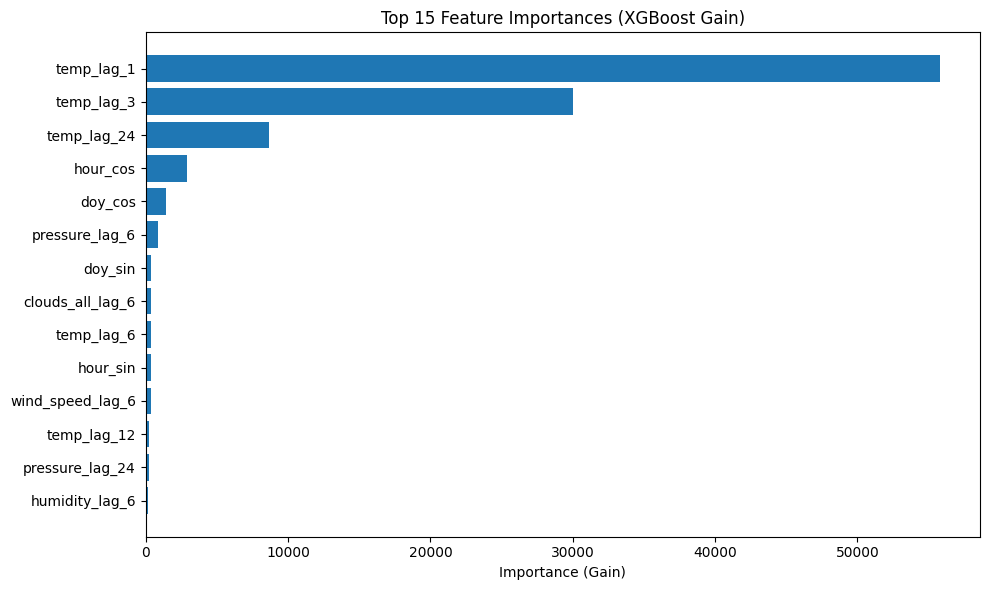

In [20]:
# ======================================================
# Feature Importance (XGBoost - Gain)
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.get_booster().get_score(importance_type="gain")

fi = (
    pd.DataFrame(
        importance.items(),
        columns=["feature", "importance"]
    )
    .sort_values("importance", ascending=False)
)

print(fi.head(15))

plt.figure(figsize=(10, 6))
plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.title("Top 15 Feature Importances (XGBoost Gain)")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()

Interpretation:

1. temp_lag_1, temp_lag_3, temp_lag_24
    --> Persistence + Daily Structure

    "How warm it is now and was yesterday is the strongest predictor for tomorrow."

2. hour_cos, doy_cos
    Daily cycle & Season:
    - hour_cos → Day/Night Cycle
    - doy_cos → Summer vs. Winter
    Very important for:
    - absolute temperature levels
    - not for weather changes

3. pressure_lag_6, pressure_lag_24
    Weather situations / Fronts:
    Pressure changes signal:
    - High/Low pressure
    - Air mass changes

    That they are not at the top is normal:
    - Karlsruhe is inland
    - Temperature 24 hours later is often still stable

4. Remaining Features: wind_speed_lag_6, clouds_all_lag_6

    Modulating Effects:

    - Wind → Advection
    - Clouds → Radiation

    --> Fine-tuning, not the main driver.


# Save Model & Preprocessing

Why save the feature list?
- The API otherwise doesn't know in which order the features must come
- prevents silent bugs

Very important:
--> Save IN the Notebook, not in the API code.

In [21]:
import joblib

# Modell speichern
joblib.dump(best_model, "models/xgboost_weather_model.joblib")

# Optional: Feature-Liste speichern (sehr wichtig!)
joblib.dump(feature_cols_xgb_ext, "models/feature_columns.joblib")


['models/feature_columns.joblib']

In [22]:
# Smoke Test to load the model and features


import joblib

model = joblib.load("models/xgboost_weather_model.joblib")
features = joblib.load("models/feature_columns.joblib")

print(type(model))
print(features)


<class 'xgboost.sklearn.XGBRegressor'>
['temp_lag_1', 'temp_lag_3', 'temp_lag_6', 'temp_lag_12', 'temp_lag_24', 'humidity_lag_6', 'pressure_lag_6', 'pressure_lag_24', 'wind_speed_lag_6', 'clouds_all_lag_6', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## Summary

This Jupyter Notebook documents a comprehensive weather forecasting project for Karlsruhe, focusing on predicting temperature 24 hours ahead (t+24) using historical data from OpenWeatherMap. The project is structured in two phases: Phase A compares multiple model classes (Naive Baseline, Linear Regression, XGBoost, Vanilla RNN, LSTM RNN, and 1D CNN) on an identical feature set to ensure fairness, while Phase B extends the best-performing model (XGBoost) with additional meteorological features for improved accuracy.

### Key Steps and Findings:
- **Data Preparation**: Loaded and cleaned hourly weather data, converted columns to appropriate types, sorted by time, and engineered features including cyclical transformations for time variables (hour and day-of-year).
- **Exploratory Data Analysis (EDA)**: Checked for missing values, visualized feature distributions, and analyzed correlations via a heatmap.
- **Phase A Model Comparison**:
    - Naive Baseline: MAE 2.25°C (reference point).
    - Linear Regression: Slight improvement (MAE 2.20°C, skill +1.9%).
    - XGBoost: Best performer (MAE 2.15°C, skill +4.2%).
    - Deep Learning Models (RNN, LSTM, CNN): Generally underperformed, with LSTM and CNN showing overfitting or negative skill, highlighting that simpler models suffice for this dataset.
- **Phase B Feature Expansion**: Extended XGBoost with lagged weather features (e.g., pressure, humidity, wind, clouds), achieving MAE 2.04°C (skill +9.29%) after hyperparameter tuning (MAE 2.03°C, skill +9.58%).
- **Feature Importance**: Temperature lags and cyclical time features dominated, with weather variables providing secondary benefits.
- **Model Saving and Testing**: Saved the tuned XGBoost model and feature list for deployment, with a smoke test confirming functionality.

### Data Limitation and Workaround:
The OpenWeatherMap API provides only current weather observations. However, the trained model requires lagged features (historical temperatures from 1, 3, 6, 12, and 24 hours prior). Due to time and resource constraints, current observations were substituted for these lag features during real-time prediction. While ideally a database would store current measurements hourly to build authentic historical data for accurate forecasting, this approach was not implemented due to resource limitations and potential compliance concerns with data retention policies. This trade-off is acknowledged as a limitation of the production deployment.

### Lessons Learned:
The project demonstrates that model complexity does not always yield better results; XGBoost with carefully selected features outperformed deep learning approaches. Feature engineering proved crucial, emphasizing persistence and temporal patterns in temperature forecasting.
